In [ ]:
# -*- coding: utf-8 -*-

In [ ]:
!pip install -q -U transformers datasets evaluate accelerate peft scikit-learn pandas matplotlib torchao

import torch

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM total: {total_vram:.2f} GB")
else:
    print("Nenhuma GPU encontrada. Vá em Ambiente de execução > Alterar tipo de ambiente de execução > GPU (T4).")

import gc
import time
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

def find_all_linear_names(model):
    """Detecta automaticamente os nomes dos módulos Linear para LoRA."""
    lora_module_names = set()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            names = name.split('.')
            lora_module_names.add(names[-1])
    lora_module_names.discard('lm_head')
    lora_module_names.discard('classifier')
    return sorted(lora_module_names)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando device:", DEVICE)

# CONFIGURAÇÃO DE MODELOS

# --- Encoder ---
ENCODER_MODEL_NAME = "Veronyka/tybyria-v2.2"
ENCODER_DTYPE = None         # None = float32 nativo. Alternativas: torch.float16, torch.bfloat16
ENCODER_MAX_LENGTH = 128     # limite de tokens na tokenização do encoder

# --- Decoder ---
DECODER_MODEL_NAME = "amadeusai/Amadeus-Verbo-MI-Qwen-2.5-3B-PT-BR-Instruct-Experimental"
DECODER_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
DECODER_MAX_LENGTH = 1024    # limite de tokens na tokenização do decoder (prompt + saída)

# --- Hiperparâmetros de avaliação do encoder ---
ENCODER_EVAL_BATCH_SIZE = 32

# --- Modo de fine-tuning do encoder ---
# "full"  = full fine-tuning (todos os pesos)
# "head"  = linear probing (só a cabeça de classificação)
# "lora"  = LoRA — low-rank adapters (~1% dos pesos)
# "all"   = roda os 3 em sequência e compara
FINETUNE_MODE = "all"

# --- Hiperparâmetros específicos por modo ---
# (cada modo ajusta LR, épocas e batch para convergência justa)
FINETUNE_CONFIG = {
    "full": {"lr": 2e-5, "epochs": 3, "batch": 16, "label": "Full fine-tuning"},
    "head": {"lr": 1e-3, "epochs": 5, "batch": 32, "label": "Linear probing"},
    "lora": {"lr": 1e-4, "epochs": 3, "batch": 16, "label": "LoRA (r=8)"},
}

# --- LoRA ---
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==

README.md:   0%|          | 0.00/35.5k [00:00<?, ?B/s]

HateBR_offensive_binary/train-00000-of-0(…): reconstructing file:   0%|          |  0.00B /  268kB            

HateBR_offensive_binary/train-00000-of-0(…): downloading bytes:           |  0.00B            

HateBR_offensive_binary/validation-00000(…): reconstructing file:   0%|          |  0.00B / 64.7kB            

HateBR_offensive_binary/validation-00000(…): downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/4480 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 4480
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1120
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1400
    })
})
{'idx': Value('int32'), 'sentence': Value('string'), 'label': ClassLabel(names=['non-offensive', 'offensive'])}
{'idx': 0, 'sentence': 'este lixo ...', 'label': 1}

Classes: ['non-offensive', 'offensive']
Coluna de texto: sentence
Coluna de rótulo: label
Treino (encoder): 1500 exemplos
Teste comum: 400 exemplos
Few-shot: 6 exemplos

Exemplos de few-shot:


,sentence,label
0,Esse entrevistado COM CERTEZA está lúcido. 😜,0
1,Parabéns pelo Luta guerreiros💪💪💪🌟🌟🌟😇😇😇🌹🌹🌹,0
2,Cara nojento,1
3,👏👏👏🏻👏 o senhor merece,0
4,"Acho pouco, o sul elegeu esse imbecil, agora t...",1
5,"🇧🇷Isso não é um jornalista, muito menos o home...",1


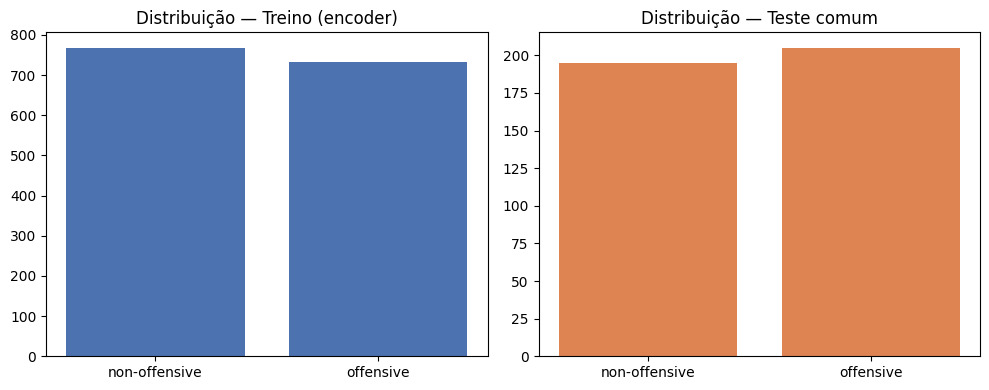

In [ ]:
SUBSET_NAME = "HateBR_offensive_binary"

dataset = load_dataset("eduagarcia/portuguese_benchmark", SUBSET_NAME)
print(dataset)

# Inspecionar as colunas e os rótulos
print(dataset["train"].features)
print(dataset["train"][0])

label_feature = dataset["train"].features["label"]
label_names = label_feature.names
print("\nClasses:", label_names)

# --- Padronizar nomes de coluna ---
TEXT_COL = "sentence" if "sentence" in dataset["train"].column_names else dataset["train"].column_names[1]
LABEL_COL = "label"

print("Coluna de texto:", TEXT_COL)
print("Coluna de rótulo:", LABEL_COL)

N_TRAIN = 1500     # exemplos para o fine-tuning do encoder
N_TEST = 400       # exemplos do teste comum (encoder e decoder)
N_FEWSHOT_PER_CLASS = 3   # exemplos de few-shot por classe (positivo/negativo)

# Embaralha o split de treino com a SEED definida, garantindo reprodutibilidade
full_train = dataset["train"].shuffle(seed=SEED)

# Seleciona os primeiros N_TRAIN exemplos do split embaralhado
train_encoder = full_train.select(range(N_TRAIN))

# Teste comum: usamos o split de teste oficial do dataset (não visto no treino)
test_full = dataset["test"].shuffle(seed=SEED)
test_common = test_full.select(range(min(N_TEST, len(test_full))))

# Few-shot: retirado do split de VALIDAÇÃO, garantindo que não há overlap com o teste comum
val_split = dataset["validation"].shuffle(seed=SEED)
val_df = val_split.to_pandas()

fewshot_rows = []
for class_idx, class_name in enumerate(label_names):
    rows = val_df[val_df[LABEL_COL] == class_idx].head(N_FEWSHOT_PER_CLASS)
    fewshot_rows.append(rows)
fewshot_df = pd.concat(fewshot_rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Treino (encoder): {len(train_encoder)} exemplos")
print(f"Teste comum: {len(test_common)} exemplos")
print(f"Few-shot: {len(fewshot_df)} exemplos")
print("\nExemplos de few-shot:")
display(fewshot_df[[TEXT_COL, LABEL_COL]])

# Visualizar a distribuição de classes em cada split, para garantir que não está desbalanceado
import matplotlib.pyplot as plt

train_counts = pd.Series(train_encoder[LABEL_COL]).value_counts().sort_index()
test_counts = pd.Series(test_common[LABEL_COL]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar([label_names[i] for i in train_counts.index], train_counts.values, color="#4C72B0")
axes[0].set_title("Distribuição — Treino (encoder)")
axes[1].bar([label_names[i] for i in test_counts.index], test_counts.values, color="#DD8452")
axes[1].set_title("Distribuição — Teste comum")
plt.tight_layout()
plt.show()

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

NUM_LABELS = len(label_names)

# --- Tokenização (idêntica para todos os modos — executa uma única vez) ---
encoder_tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL_NAME)

def tokenize_function(examples):
    return encoder_tokenizer(
        examples[TEXT_COL], truncation=True, max_length=ENCODER_MAX_LENGTH
    )

train_tokenized = train_encoder.map(tokenize_function, batched=True)
test_tokenized = test_common.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.rename_column(LABEL_COL, "labels")
test_tokenized = test_tokenized.rename_column(LABEL_COL, "labels")

keep_cols = ["input_ids", "attention_mask", "labels"]
train_tokenized = train_tokenized.remove_columns(
    [c for c in train_tokenized.column_names if c not in keep_cols]
)
test_tokenized = test_tokenized.remove_columns(
    [c for c in test_tokenized.column_names if c not in keep_cols]
)

data_collator = DataCollatorWithPadding(tokenizer=encoder_tokenizer)

def compute_metrics_encoder(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

# --- Determinar quais modos rodar ---
modes_to_run = ["full", "head", "lora"] if FINETUNE_MODE == "all" else [FINETUNE_MODE]
encoder_results_list = []

for mode_idx, mode in enumerate(modes_to_run):
    print(f"\n{'='*60}")
    print(f"  MODO: {mode} — {FINETUNE_CONFIG[mode]['label']}")
    print(f"{'='*60}\n")

    # --- Reset VRAM (exceto na primeira iteração) ---
    if mode_idx > 0:
        print(f"VRAM alocada ANTES do reset: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")
        for var_name in ["encoder_model", "trainer", "collated", "outputs", "peft_model"]:
            if var_name in globals():
                del globals()[var_name]
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print(f"VRAM alocada DEPOIS do reset: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")

    # --- Carregar modelo conforme o modo ---
    if mode == "lora":
        from peft import LoraConfig, get_peft_model, TaskType

    base_model = AutoModelForSequenceClassification.from_pretrained(
        ENCODER_MODEL_NAME, num_labels=NUM_LABELS,
        torch_dtype=ENCODER_DTYPE,
    ).to(DEVICE)

    if mode == "full":
        encoder_model = base_model
        print("Modo FULL: todos os pesos serão atualizados.")

    elif mode == "head":
        for param in base_model.parameters():
            param.requires_grad = False
        for param in base_model.classifier.parameters():
            param.requires_grad = True
        encoder_model = base_model
        trainable = sum(p.numel() for p in encoder_model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in encoder_model.parameters())
        print(f"Modo HEAD: apenas {trainable:,} / {total:,} parâmetros treináveis ({100*trainable/total:.2f}%).")

    elif mode == "lora":
        target_modules = find_all_linear_names(base_model)
        print(f"LoRA target_modules detectados: {target_modules}")
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=target_modules,
        )
        encoder_model = get_peft_model(base_model, lora_config)
        trainable = sum(p.numel() for p in encoder_model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in encoder_model.parameters())
        print(f"Modo LORA: {trainable:,} / {total:,} parâmetros treináveis ({100*trainable/total:.2f}%).")

    # --- Trainer ---
    cfg = FINETUNE_CONFIG[mode]


    training_args = TrainingArguments(
    output_dir=f"./encoder_checkpoints_{mode}",
    learning_rate=cfg["lr"],                       # usa o LR específico do modo (full/head/lora)
    num_train_epochs=cfg["epochs"],                # usa as épocas específicas do modo
    per_device_train_batch_size=cfg["batch"],      # usa o batch específico do modo
    per_device_eval_batch_size=ENCODER_EVAL_BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=20,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

    trainer = Trainer(
        model=encoder_model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized,
        data_collator=data_collator,
        compute_metrics=compute_metrics_encoder,
    )

    train_result = trainer.train()
    print(train_result)

    # --- Avaliação: Acurácia, F1, Tempo e VRAM ---
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    encoder_model.eval()
    all_preds = []
    all_labels = []

    batch_size = ENCODER_EVAL_BATCH_SIZE
    start_time = time.time()

    with torch.no_grad():
        for i in range(0, len(test_tokenized), batch_size):
            batch = test_tokenized[i : i + batch_size]
            features = [
                {"input_ids": batch["input_ids"][j], "attention_mask": batch["attention_mask"][j]}
                for j in range(len(batch["input_ids"]))
            ]
            collated = data_collator(features)
            collated = {k: v.to(DEVICE) for k, v in collated.items()}

            outputs = encoder_model(**collated)
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

            all_preds.extend(preds.tolist())
            all_labels.extend(batch["labels"])

    encoder_inference_time = time.time() - start_time
    encoder_peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3

    encoder_accuracy = accuracy_score(all_labels, all_preds)
    encoder_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\n--- Resultados ({FINETUNE_CONFIG[mode]['label']}) ---")
    print(f"Acurácia: {encoder_accuracy:.4f}")
    print(f"F1 (macro): {encoder_f1:.4f}")
    print(f"Tempo de inferência ({len(test_tokenized)} exemplos): {encoder_inference_time:.2f} s")
    print(f"Pico de VRAM durante a inferência: {encoder_peak_vram_gb:.3f} GB")
    print("\nRelatório de classificação:\n")
    print(classification_report(all_labels, all_preds, target_names=label_names))

    encoder_results_list.append({
        "modelo": f"{ENCODER_MODEL_NAME.split('/')[-1]} ({FINETUNE_CONFIG[mode]['label']})",
        "acuracia": encoder_accuracy,
        "f1_macro": encoder_f1,
        "tempo_inferencia_s": encoder_inference_time,
        "vram_pico_gb": encoder_peak_vram_gb,
        "tempo_por_exemplo_ms": (encoder_inference_time / len(test_tokenized)) * 1000,
        "modo": mode,
    })

# Exibir resumo de todos os modos de encoder
encoder_results_df = pd.DataFrame(encoder_results_list).set_index("modelo")
encoder_results_list

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/678k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

...

LoRA target_modules detectados: ['dense', 'key', 'query', 'value']
Modo LORA: 1,340,930 / 110,265,604 parâmetros treináveis (1.22%).


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.382897,0.339252,0.857500,0.857349
2,0.268727,0.294753,0.872500,0.872461
3,0.266788,0.299870,0.872500,0.872461


TrainOutput(global_step=282, training_loss=0.3222978520900645, metrics={'train_runtime': 31.8818, 'train_samples_per_second': 141.146, 'train_steps_per_second': 8.845, 'total_flos': 174438814061760.0, 'train_loss': 0.3222978520900645, 'epoch': 3.0})

--- Resultados (LoRA (r=8)) ---
Acurácia: 0.8725
F1 (macro): 0.8725
Tempo de inferência (400 exemplos): 0.76 s
Pico de VRAM durante a inferência: 0.577 GB

Relatório de classificação:

               precision    recall  f1-score   support

non-offensive       0.84      0.91      0.87       195
    offensive       0.91      0.83      0.87       205

     accuracy                           0.87       400
    macro avg       0.87      0.87      0.87       400
 weighted avg       0.88      0.87      0.87       400



[{'modelo': 'tybyria-v2.2 (Full fine-tuning)',
  'acuracia': 0.9,
  'f1_macro': 0.8999974999374984,
  'tempo_inferencia_s': 0.4688088893890381,
  'vram_pico_gb': 1.5259218215942383,
  'tempo_por_exemplo_ms': 1.1720222234725952,
  'modo': 'full'},
 {'modelo': 'tybyria-v2.2 (Linear probing)',
  'acuracia': 0.835,
  'f1_macro': 0.8349958748968724,
  'tempo_inferencia_s': 0.4402298927307129,
  'vram_pico_gb': 0.5135207176208496,
  'tempo_por_exemplo_ms': 1.1005747318267822,
  'modo': 'head'},
 {'modelo': 'tybyria-v2.2 (LoRA (r=8))',
  'acuracia': 0.8725,
  'f1_macro': 0.8724609411632313,
  'tempo_inferencia_s': 0.7644143104553223,
  'vram_pico_gb': 0.5767111778259277,
  'tempo_por_exemplo_ms': 1.9110357761383057,
  'modo': 'lora'}]

In [ ]:
print(f"VRAM alocada ANTES do reset: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")

# 1. Apagar referências ao modelo, trainer e tensores do encoder
for var_name in ["encoder_model", "trainer", "train_tokenized", "test_tokenized", "collated", "outputs"]:
    if var_name in globals():
        del globals()[var_name]

# 2. Coletor de lixo do Python
gc.collect()

# 3. Esvaziar o cache de memória do PyTorch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"VRAM alocada DEPOIS do reset: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")

VRAM alocada ANTES do reset: 0.439 GB
VRAM alocada DEPOIS do reset: 0.429 GB


In [ ]:
from transformers import AutoModelForCausalLM

decoder_tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL_NAME)
decoder_model = AutoModelForCausalLM.from_pretrained(
    DECODER_MODEL_NAME,
    torch_dtype=DECODER_DTYPE,
).to(DEVICE)

decoder_model.eval()

if decoder_tokenizer.pad_token is None:
    decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

print("Decoder carregado:", DECODER_MODEL_NAME)
print(f"VRAM alocada após carregar o decoder: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")

config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/33.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Decoder carregado: amadeusai/Amadeus-Verbo-MI-Qwen-2.5-3B-PT-BR-Instruct-Experimental
VRAM alocada após carregar o decoder: 6.283 GB


In [ ]:
# Nomes "amigáveis" para os rótulos, usados no prompt
LABEL_TO_TEXT = {0: "não ofensivo", 1: "ofensivo"}
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}

SYSTEM_PROMPT = (
    "Você é um classificador de texto. Sua única tarefa é responder com "
    "'ofensivo' ou 'não ofensivo' para o comentário fornecido, sem explicações."
)

def build_fewshot_messages(target_sentence, fewshot_df, text_col=TEXT_COL, label_col=LABEL_COL):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for _, row in fewshot_df.iterrows():
        label_text = LABEL_TO_TEXT[row[label_col]]
        messages.append({"role": "user", "content": f"Comentário: {row[text_col]}"})
        messages.append({"role": "assistant", "content": label_text})

    messages.append({"role": "user", "content": f"Comentário: {target_sentence}"})
    return messages


# Sanity check: olhar como fica o prompt formatado de um exemplo
example_messages = build_fewshot_messages(test_common[0][TEXT_COL], fewshot_df)
example_prompt_text = decoder_tokenizer.apply_chat_template(
    example_messages, tokenize=False, add_generation_prompt=True
)
print(example_prompt_text)

# Verificar quantos tokens o prompt few-shot ocupa (sem a pergunta do teste)
fewshot_only_messages = example_messages[:-1]  # sem a última mensagem (pergunta)
fewshot_tokens = len(decoder_tokenizer.apply_chat_template(
    fewshot_only_messages, tokenize=True, add_generation_prompt=False
))
print(f"\nTokens do prompt few-shot (sem a pergunta): {fewshot_tokens}")
print(f"Tokens disponíveis para pergunta + resposta: {DECODER_MAX_LENGTH - fewshot_tokens}")

if fewshot_tokens > DECODER_MAX_LENGTH * 0.5:
    print("⚠️  ALERTA: os exemplos few-shot ocupam mais de 50% do limite de tokens!")
    print("   Reduza N_FEWSHOT_PER_CLASS ou encurrte os exemplos para evitar truncamento.")
if fewshot_tokens >= DECODER_MAX_LENGTH:
    raise RuntimeError(
        f"Prompt few-shot ({fewshot_tokens} tokens) excede DECODER_MAX_LENGTH ({DECODER_MAX_LENGTH}). "
        "A pergunta do teste será truncada. Reduza N_FEWSHOT_PER_CLASS ou aumente DECODER_MAX_LENGTH."
    )

<|im_start|>system
Você é um classificador de texto. Sua única tarefa é responder com 'ofensivo' ou 'não ofensivo' para o comentário fornecido, sem explicações.<|im_end|>
<|im_start|>user
Comentário: Esse entrevistado COM CERTEZA está lúcido. 😜<|im_end|>
<|im_start|>assistant
não ofensivo<|im_end|>
<|im_start|>user
Comentário: Parabéns pelo Luta guerreiros💪💪💪🌟🌟🌟😇😇😇🌹🌹🌹<|im_end|>
<|im_start|>assistant
não ofensivo<|im_end|>
<|im_start|>user
Comentário: Cara nojento<|im_end|>
<|im_start|>assistant
ofensivo<|im_end|>
<|im_start|>user
Comentário: 👏👏👏🏻👏 o senhor merece<|im_end|>
<|im_start|>assistant
não ofensivo<|im_end|>
<|im_start|>user
Comentário: Acho pouco, o sul elegeu esse imbecil, agora toma!<|im_end|>
<|im_start|>assistant
ofensivo<|im_end|>
<|im_start|>user
Comentário: 🇧🇷Isso não é um jornalista, muito menos o homem, mas sim um Cafajeste, um crápula, um bicho ruim de chifre, rabo e garfo na pata, um ABUTRE com um microfone na mão. Acho que nem a mãe dele ele respeita como mulher. 

In [ ]:

def parse_decoder_output(generated_text):
    text = generated_text.strip().lower()
    text = re.sub(r"[^\w\sãáàâéêíóôõúç]", "", text)  # remove pontuação

    # Verifica "não ofensivo" / "nao ofensivo" ANTES de "ofensivo",
    # pois a substring "ofensivo" aparece dentro de "não ofensivo".
    if "nao ofensivo" in text or "não ofensivo" in text or "não ofens" in text or "nao ofens" in text:
        return 0
    if "ofensivo" in text:
        return 1
    return None  # não foi possível interpretar a saída com segurança

# --- Inferência do decoder no MESMO conjunto de teste (test_common) ---
torch.cuda.reset_peak_memory_stats()
torch.cuda.empty_cache()

decoder_preds = []
decoder_labels = []
raw_outputs = []

start_time = time.time()

with torch.no_grad():
    for example in test_common:
        messages = build_fewshot_messages(example[TEXT_COL], fewshot_df)
        inputs = decoder_tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            truncation=True,
            max_length=DECODER_MAX_LENGTH,
        ).to(DEVICE)

        output_ids = decoder_model.generate(
            **inputs,
            max_new_tokens=4,
            do_sample=False,
            pad_token_id=decoder_tokenizer.pad_token_id,
        )

        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        generated_text = decoder_tokenizer.decode(new_tokens, skip_special_tokens=True)

        pred_label = parse_decoder_output(generated_text)
        raw_outputs.append(generated_text)
        decoder_preds.append(pred_label)
        decoder_labels.append(example[LABEL_COL])

decoder_inference_time = time.time() - start_time
decoder_peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3

print(f"Tempo total de inferência ({len(test_common)} exemplos): {decoder_inference_time:.2f} s")
print(f"Pico de VRAM durante a inferência: {decoder_peak_vram_gb:.3f} GB")

Tempo total de inferência (400 exemplos): 464.36 s
Pico de VRAM durante a inferência: 6.363 GB


In [ ]:
# Quantos exemplos o modelo respondeu de forma "não interpretável"?
n_invalid = sum(1 for p in decoder_preds if p is None)
print(f"Saídas não interpretáveis: {n_invalid} de {len(decoder_preds)} ({n_invalid/len(decoder_preds)*100:.1f}%)")

# Visualizar alguns exemplos de saída bruta do modelo
preview_df = pd.DataFrame({
    "comentario": [test_common[i][TEXT_COL] for i in range(10)],
    "saida_bruta_decoder": raw_outputs[:10],
    "classe_extraida": [decoder_preds[i] for i in range(10)],
    "classe_real": [decoder_labels[i] for i in range(10)],
})
display(preview_df)

# --- Métricas do decoder ---
# Exemplos com saída não interpretável são tratados como "erro" (classe incorreta atribuída),
# o que é justo: o objetivo da tarefa é produzir uma resposta utilizável.

FALLBACK_LABEL = 1 - decoder_labels[0]  # rótulo "neutro" de fallback, só para não quebrar o cálculo
decoder_preds_clean = [p if p is not None else FALLBACK_LABEL for p in decoder_preds]

decoder_accuracy = accuracy_score(decoder_labels, decoder_preds_clean)
decoder_f1 = f1_score(decoder_labels, decoder_preds_clean, average="macro")

print(f"Acurácia: {decoder_accuracy:.4f}")
print(f"F1 (macro): {decoder_f1:.4f}")
print(f"Tempo de inferência (teste completo, {len(test_common)} exemplos): {decoder_inference_time:.2f} s")
print(f"Pico de VRAM durante a inferência: {decoder_peak_vram_gb:.3f} GB")
print("\nRelatório de classificação:\n")
print(classification_report(decoder_labels, decoder_preds_clean, target_names=label_names))

decoder_results = {
    "modelo": f"{DECODER_MODEL_NAME.split('/')[-1]} (decoder, few-shot)",
    "acuracia": decoder_accuracy,
    "f1_macro": decoder_f1,
    "tempo_inferencia_s": decoder_inference_time,
    "vram_pico_gb": decoder_peak_vram_gb,
    "tempo_por_exemplo_ms": (decoder_inference_time / len(test_common)) * 1000,
    "modo": "decoder",
}
decoder_results

Saídas não interpretáveis: 0 de 400 (0.0%)


,comentario,saida_bruta_decoder,classe_extraida,classe_real
0,À vitória! ✊,não ofens,0,0
1,Velho escroto!,ofensivo,1,1
2,Pois é 🤔,não ofens,0,0
3,"😂😂 abstinência de propina faz isso, cria até p...",não ofens,0,1
4,😂 pra mim não precisa disso,não ofens,0,0
5,Noventa comunista,ofensivo,1,1
6,@patriciamnds como lidar com esse encontro de ...,não ofens,0,0
7,Cara pálida devolve o dinheiro a propina para ...,ofensivo,1,1
8,Dois lindos e incríveis!,não ofens,0,0
9,Incrível 👏👏👏👏👏,não ofens,0,0


Acurácia: 0.8475
F1 (macro): 0.8473
Tempo de inferência (teste completo, 400 exemplos): 464.36 s
Pico de VRAM durante a inferência: 6.363 GB

Relatório de classificação:

               precision    recall  f1-score   support

non-offensive       0.81      0.90      0.85       195
    offensive       0.90      0.80      0.84       205

     accuracy                           0.85       400
    macro avg       0.85      0.85      0.85       400
 weighted avg       0.85      0.85      0.85       400



{'modelo': 'Amadeus-Verbo-MI-Qwen-2.5-3B-PT-BR-Instruct-Experimental (decoder, few-shot)',
 'acuracia': 0.8475,
 'f1_macro': 0.8473387515563313,
 'tempo_inferencia_s': 464.3608226776123,
 'vram_pico_gb': 6.3633341789245605,
 'tempo_por_exemplo_ms': 1160.9020566940308,
 'modo': 'decoder'}

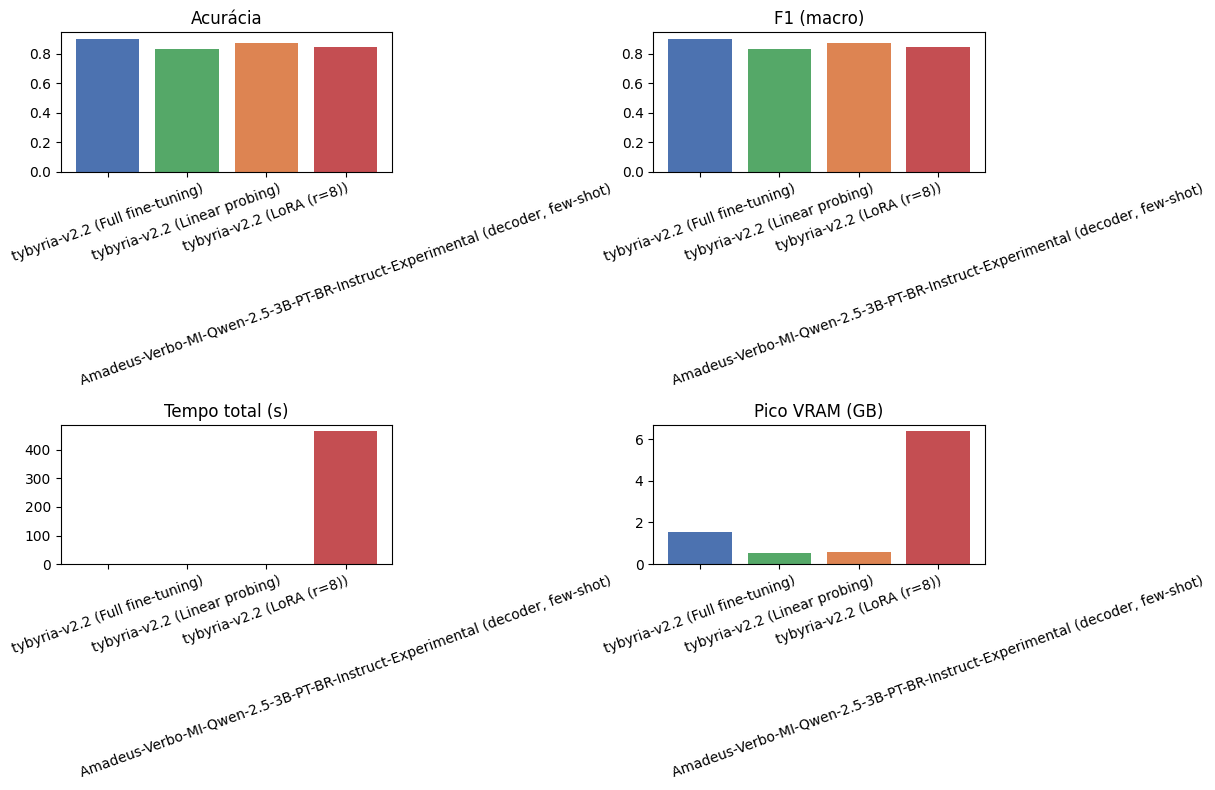

In [ ]:
# Juntar todos os resultados de encoder com o decoder
all_rows = encoder_results_list + [decoder_results]
comparison_df = pd.DataFrame(all_rows).set_index("modelo")
comparison_df = comparison_df.rename(columns={
    "acuracia": "Acurácia",
    "f1_macro": "F1 (macro)",
    "tempo_inferencia_s": "Tempo total (s)",
    "vram_pico_gb": "Pico VRAM (GB)",
    "tempo_por_exemplo_ms": "Tempo / exemplo (ms)",
})
comparison_df.round(4)

# Cores consistentes: mesmo modo sempre tem a mesma cor
COLOR_MAP = {"full": "#4C72B0", "head": "#55A868", "lora": "#DD8452", "decoder": "#C44E52"}
bar_colors = [COLOR_MAP.get(row.get("modo", "decoder"), "#333333") for row in all_rows]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_to_plot = [
    ("Acurácia", axes[0, 0]),
    ("F1 (macro)", axes[0, 1]),
    ("Tempo total (s)", axes[1, 0]),
    ("Pico VRAM (GB)", axes[1, 1]),
]

for metric_name, ax in metrics_to_plot:
    ax.bar(comparison_df.index, comparison_df[metric_name], color=bar_colors)
    ax.set_title(metric_name)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("comparacao_encoder_decoder.png", dpi=150)
plt.show()